# Housing Price Prediction Using Simple Linear Regression

## Objective
The objective of this project is to predict housing prices using Simple Linear Regression.

The California Housing dataset contains information related to housing characteristics such as total rooms, population, median income, and location.

In this project, **Total Rooms** is selected as the independent variable and **Median House Value** is selected as the target variable.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [54]:
df = pd.read_csv(r"C:\Users\vaish\Downloads\archive (1)\housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [55]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (20640, 10)

Column Names:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [56]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [57]:
missing_values = df.isnull().sum()

print(missing_values)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [58]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

print("Missing values handled successfully.")

Missing values handled successfully.


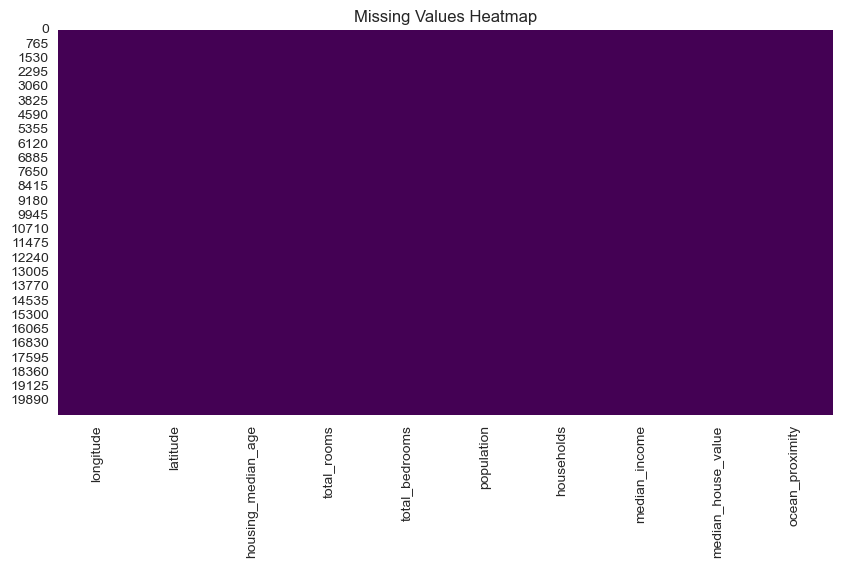

In [59]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

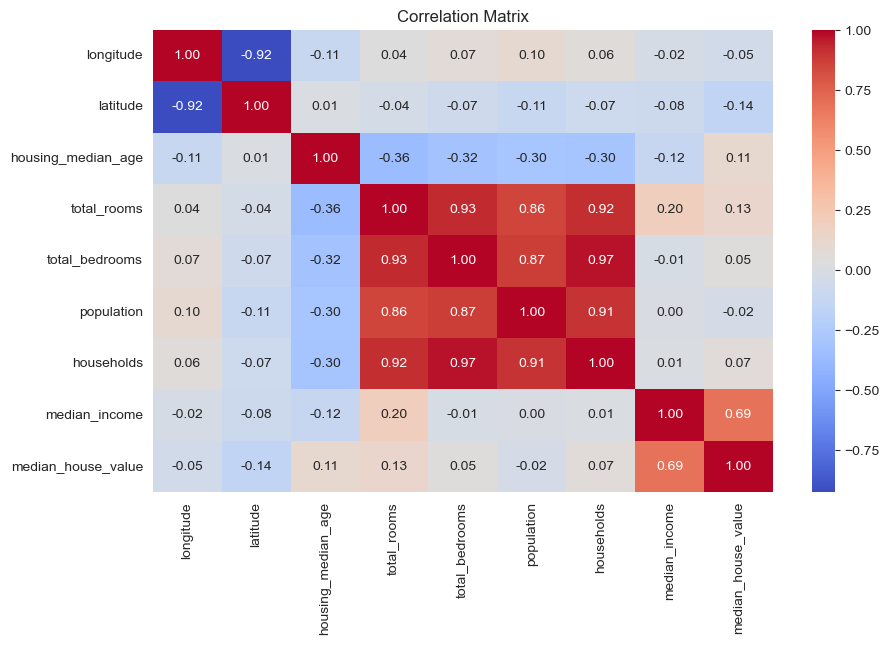

In [60]:
plt.figure(figsize=(10,6))

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [61]:
X = df[["total_rooms"]]

y = df["median_house_value"]

print("Feature Selected: total_rooms")
print("Target Selected: median_house_value")

Feature Selected: total_rooms
Target Selected: median_house_value


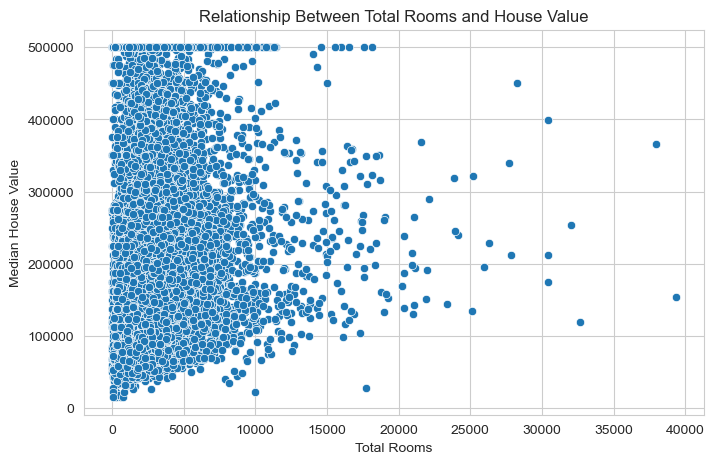

In [62]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="total_rooms",
    y="median_house_value"
)

plt.title("Relationship Between Total Rooms and House Value")

plt.xlabel("Total Rooms")

plt.ylabel("Median House Value")

plt.show()

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 16512
Testing Samples: 4128


In [64]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [65]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [66]:
predictions = linear_model.predict(
    X_test_scaled
)

predictions[:10]

array([199094.68673261, 209338.97966208, 215657.95589882, 210108.3702298 ,
       205121.57951309, 219910.9759815 , 198168.56845665, 197883.60898712,
       204701.26429554, 204986.22376506])

In [67]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    predictions
)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R² Score :", r2)

Mean Absolute Error : 89419.4255544871
Mean Squared Error : 12868608472.627419
Root Mean Squared Error : 113439.88924812744
R² Score : 0.017970062300526224


In [68]:
result_df = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": predictions
})

result_df.head(10)

,Actual Value,Predicted Value
0,47700.0,199094.686733
1,45800.0,209338.979662
2,500001.0,215657.955899
3,218600.0,210108.370230
4,278000.0,205121.579513
5,158700.0,219910.975981
6,198200.0,198168.568457
7,157500.0,197883.608987
8,340000.0,204701.264296
9,446600.0,204986.223765


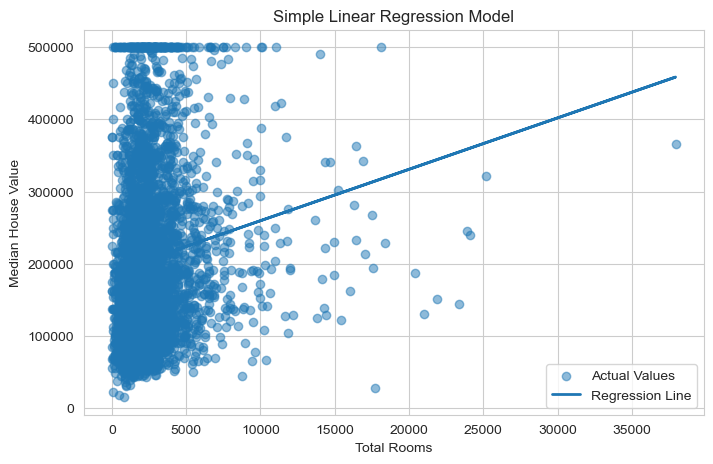

In [69]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual Values"
)

plt.plot(
    X_test,
    predictions,
    linewidth=2,
    label="Regression Line"
)

plt.title("Simple Linear Regression Model")

plt.xlabel("Total Rooms")

plt.ylabel("Median House Value")

plt.legend()

plt.show()

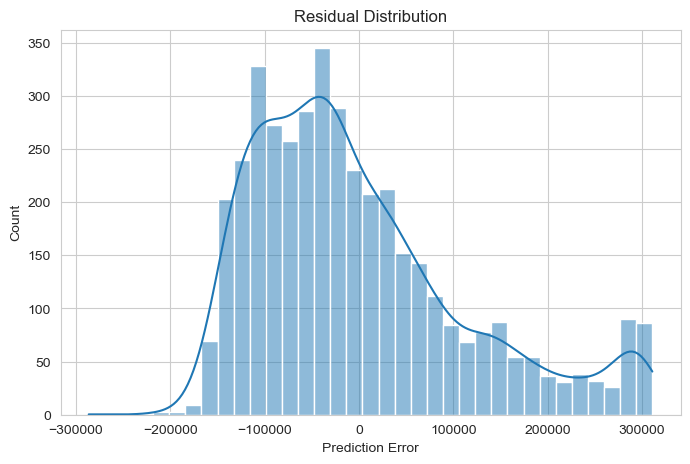

In [70]:
residuals = y_test - predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

# Conclusion

A Simple Linear Regression model was developed to predict housing prices using the total number of rooms as the predictor variable.

The dataset was explored, cleaned, and analyzed using statistical and visualization techniques. Missing values were handled using median imputation, and feature scaling was applied before model training.

The model was evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The results indicate a positive relationship between the number of rooms and housing prices. This project demonstrates the practical implementation of Simple Linear Regression for housing price prediction using real-world data.